# South Korea 2026 FIFA World Cup Performance Analysis: Why Did the Results Fall Short?

## A Data-Driven Diagnosis of Finishing, Chance Creation, and Tactical Efficiency

This project analyzes South Korea's 2026 World Cup group-stage performance using match-level statistics such as expected goals (xG), possession, shots, shots on target, big chances, and touches in the opposition box. The goal is to evaluate whether South Korea's underperformance was mainly driven by poor finishing, weak chance creation, defensive issues, or tactical inefficiency.

Rather than relying on subjective impressions, this analysis uses quantitative indicators to compare South Korea's attacking and defensive output against its opponents across the group stage.


## Data Description

The dataset was manually collected from publicly available match statistics for South Korea's three 2026 FIFA World Cup group-stage matches. Each row represents one match and includes team-level performance indicators such as goals, expected goals (xG), possession percentage, shots, shots on target, big chances, touches in the opposition box, and source URL.

All statistics are recorded from South Korea's perspective. For example, `xg_for` refers to South Korea's expected goals, while `xg_against` refers to the opponent's expected goals.

Because the dataset contains only three group-stage matches, this project should be interpreted as a small match-level diagnostic analysis rather than a complete evaluation of South Korean football.


## Research Question

Did South Korea underperform in the 2026 World Cup because of poor individual execution, inefficient attacking structure, defensive vulnerability, or a combination of these factors?

To answer this, I focus on four key areas:

1. **Finishing efficiency**: Did South Korea score fewer goals than expected based on xG?
2. **Chance creation**: Did South Korea create enough quality chances?
3. **Shot quality**: Were South Korea's shots generally dangerous or low-quality?
4. **Tactical efficiency**: Did high possession translate into meaningful attacking output?


## 1. Import Libraries and Load Data

In [14]:
import pandas as pd
import sqlite3
import matplotlib.pyplot as plt
import numpy as np
df = pd.read_csv("korea26.csv")
df

,match_date,opponent,result,goals_for,goals_against,xg_for,xg_against,possession_for_pct,possession_against_pct,shots_for,shots_against,shots_on_target_for,shots_on_target_against,big_chances_for,big_chances_against,touches_box_for,touches_box_against,source_url
0,2026-06-11,Czechia,W,2,1,2.30,0.83,62,38,15,7,6,4,4,1,24,12,https://www.fotmob.com/matches/south-korea-vs-...
1,2026-06-19,Mexico,L,0,1,0.91,0.53,58,42,9,8,2,4,3,2,11,6,https://www.fotmob.com/matches/mexico-vs-south...
2,2026-06-24,South Africa,L,0,1,0.90,1.16,68,32,8,13,3,4,1,1,18,13,https://www.fotmob.com/matches/south-africa-vs...


## 2. Store the Dataset in SQLite

In [15]:
conn = sqlite3.connect(":memory:")
rows_inserted = df.to_sql("korea_match_stats", conn, index=False, if_exists="replace")
print(f"{rows_inserted} rows inserted into korea_match_stats.")

3 rows inserted into korea_match_stats.


## 3. Match-Level Performance Metrics

In [16]:
query = """
SELECT
    opponent,
    result,
    goals_for,
    goals_against,
    xg_for,
    xg_against,
    ROUND(goals_for - xg_for, 2) AS finishing_gap,
    ROUND(goals_against - xg_against, 2) AS defensive_gap,
    ROUND(xg_for - xg_against, 2) AS xg_difference,
    possession_for_pct,
    shots_for,
    shots_against,
    shots_on_target_for,
    shots_on_target_against,
    big_chances_for,
    big_chances_against,
    touches_box_for,
    touches_box_against,
    ROUND(xg_for / NULLIF(shots_for, 0), 3) AS xg_per_shot,
    ROUND(xg_against / NULLIF(shots_against, 0), 3) AS opponent_xg_per_shot
FROM korea_match_stats;
"""

match_analysis = pd.read_sql_query(query, conn)

# Change the displayed table index from 0,1,2 to 1,2,3
match_analysis.index = range(1, len(match_analysis) + 1)

match_analysis

,opponent,result,goals_for,goals_against,xg_for,xg_against,finishing_gap,defensive_gap,xg_difference,possession_for_pct,shots_for,shots_against,shots_on_target_for,shots_on_target_against,big_chances_for,big_chances_against,touches_box_for,touches_box_against,xg_per_shot,opponent_xg_per_shot
1,Czechia,W,2,1,2.30,0.83,-0.30,0.17,1.47,62,15,7,6,4,4,1,24,12,0.153,0.119
2,Mexico,L,0,1,0.91,0.53,-0.91,0.47,0.38,58,9,8,2,4,3,2,11,6,0.101,0.066
3,South Africa,L,0,1,0.90,1.16,-0.90,-0.16,-0.26,68,8,13,3,4,1,1,18,13,0.113,0.089


This query calculates match-level performance indicators including finishing gap, defensive gap, xG difference, xG per shot, and opponent xG per shot.

- `finishing_gap = goals_for - xg_for`
  - Negative values indicate that South Korea scored fewer goals than expected.
- `defensive_gap = goals_against - xg_against`
  - Positive values indicate that opponents scored more goals than expected.
- `xg_difference = xg_for - xg_against`
  - Positive values indicate that South Korea created better chances than its opponent.
- `xg_per_shot = xg_for / shots_for`
  - Higher values indicate better average shot quality.

## 4. Group Stage Summary

In [17]:
summary_query = """
SELECT
    COUNT(*) AS matches,
    SUM(goals_for) AS total_goals_for,
    ROUND(SUM(xg_for), 2) AS total_xg_for,
    ROUND(SUM(goals_for) - SUM(xg_for), 2) AS total_finishing_gap,
    SUM(goals_against) AS total_goals_against,
    ROUND(SUM(xg_against), 2) AS total_xg_against,
    ROUND(SUM(goals_against) - SUM(xg_against), 2) AS total_defensive_gap,
    ROUND(AVG(possession_for_pct), 1) AS avg_possession_pct,
    SUM(shots_for) AS total_shots_for,
    SUM(shots_against) AS total_shots_against,
    SUM(shots_on_target_for) AS total_sot_for,
    SUM(shots_on_target_against) AS total_sot_against,
    ROUND(SUM(xg_for) / NULLIF(SUM(shots_for), 0), 3) AS xg_per_shot,
    ROUND(SUM(xg_against) / NULLIF(SUM(shots_against), 0), 3) AS opponent_xg_per_shot
FROM korea_match_stats;
"""

summary = pd.read_sql_query(summary_query, conn)
summary

,matches,total_goals_for,total_xg_for,total_finishing_gap,total_goals_against,total_xg_against,total_defensive_gap,avg_possession_pct,total_shots_for,total_shots_against,total_sot_for,total_sot_against,xg_per_shot,opponent_xg_per_shot
0,3,2,4.11,-2.11,3,2.52,0.48,62.7,32,28,11,12,0.128,0.09


## Summary of Findings

Across the three group-stage matches, South Korea recorded:

* **2 actual goals** from **4.11 expected goals**
* A **finishing gap of -2.11**
* **3 goals conceded** from **2.52 opponent expected goals**
* An average possession rate of **62.7%**
* **32 total shots** compared to opponents' **28 total shots**
* **11 shots on target** compared to opponents' **12 shots on target**
* **0.128 xG per shot** compared to opponents' **0.090 xG per shot**

These results suggest that South Korea was not heavily outplayed in overall match statistics. The team produced more total shots, higher total xG, and higher xG per shot than its opponents. However, South Korea significantly underperformed its expected goals, scoring only 2 goals from 4.11 xG.

The most visible issue in the data is therefore **finishing and chance conversion**. South Korea created enough chances to score more than it did, but failed to convert those opportunities into goals.

At the same time, the possession data suggests that tactical efficiency should also be examined. South Korea averaged 62.7% possession, but this did not consistently translate into goals or match results. This raises a further question about whether the team’s possession was effective in creating high-quality attacking situations, especially in matches where South Korea controlled the ball but failed to score.


## 5. Finishing and Shot Efficiency

This section examines whether South Korea's attacking problem was caused by a lack of chances or by poor execution after chances were created. The key indicators are shot-on-target rate, goals per shot, goals per shot on target, and finishing gap.

In [18]:
efficiency_query = """
SELECT
    opponent,
    result,
    goals_for,
    xg_for,
    shots_for,
    shots_on_target_for,
    ROUND(shots_on_target_for * 1.0 / NULLIF(shots_for, 0), 3) AS shot_on_target_rate,
    ROUND(goals_for * 1.0 / NULLIF(shots_for, 0), 3) AS goal_per_shot,
    ROUND(goals_for * 1.0 / NULLIF(shots_on_target_for, 0), 3) AS goal_per_shot_on_target,
    ROUND(goals_for - xg_for, 2) AS finishing_gap,
    possession_for_pct,
    touches_box_for,
    big_chances_for
FROM korea_match_stats;
"""

efficiency = pd.read_sql_query(efficiency_query, conn)

# Change the displayed table index from 0,1,2 to 1,2,3
efficiency.index = range(1, len(efficiency) + 1)

efficiency

,opponent,result,goals_for,xg_for,shots_for,shots_on_target_for,shot_on_target_rate,goal_per_shot,goal_per_shot_on_target,finishing_gap,possession_for_pct,touches_box_for,big_chances_for
1,Czechia,W,2,2.30,15,6,0.400,0.133,0.333,-0.30,62,24,4
2,Mexico,L,0,0.91,9,2,0.222,0.000,0.000,-0.91,58,11,3
3,South Africa,L,0,0.90,8,3,0.375,0.000,0.000,-0.90,68,18,1


## 6. Match-by-Match Diagnosis

This section classifies each match based on the main statistical issue shown in the data. The goal is not to prove a single cause, but to identify whether each match was more strongly associated with finishing, chance creation, defensive vulnerability, or tactical efficiency.

In [19]:
diagnosis_query = """
SELECT
    opponent,
    result,
    goals_for,
    goals_against,
    xg_for,
    xg_against,
    ROUND(goals_for - xg_for, 2) AS finishing_gap,
    ROUND(xg_for - xg_against, 2) AS xg_difference,
    possession_for_pct,
    shots_for,
    shots_on_target_for,
    ROUND(shots_on_target_for * 1.0 / NULLIF(shots_for, 0), 3) AS shot_on_target_rate,
    ROUND(xg_for / NULLIF(shots_for, 0), 3) AS xg_per_shot,
    CASE
        WHEN possession_for_pct >= 60 AND xg_for < 1.0 THEN 'Tactical efficiency issue'
        WHEN goals_for - xg_for <= -0.75 THEN 'Finishing issue'
        WHEN xg_for - xg_against < 0 THEN 'Chance creation / defensive issue'
        ELSE 'Acceptable underlying performance'
    END AS primary_diagnosis
FROM korea_match_stats;
"""

diagnosis = pd.read_sql_query(diagnosis_query, conn)
diagnosis.index = range(1, len(diagnosis) + 1)

diagnosis

,opponent,result,goals_for,goals_against,xg_for,xg_against,finishing_gap,xg_difference,possession_for_pct,shots_for,shots_on_target_for,shot_on_target_rate,xg_per_shot,primary_diagnosis
1,Czechia,W,2,1,2.30,0.83,-0.30,1.47,62,15,6,0.400,0.153,Acceptable underlying performance
2,Mexico,L,0,1,0.91,0.53,-0.91,0.38,58,9,2,0.222,0.101,Finishing issue
3,South Africa,L,0,1,0.90,1.16,-0.90,-0.26,68,8,3,0.375,0.113,Tactical efficiency issue


The diagnosis table suggests that South Korea's problems were not identical across all three matches. Some matches show stronger evidence of finishing issues, while others raise questions about whether possession translated into meaningful attacking output. This helps avoid a simplistic conclusion that the team was simply "bad" overall.

## 7. Possession Productivity

This section examines whether South Korea's possession was productive. High possession does not necessarily mean strong attacking performance, so I calculate how much xG, shots, and box touches South Korea generated relative to its possession share.

In [20]:
possession_query = """
SELECT
    opponent,
    result,
    possession_for_pct,
    xg_for,
    shots_for,
    touches_box_for,
    ROUND(xg_for / NULLIF(possession_for_pct, 0), 3) AS xg_per_possession_pct,
    ROUND(shots_for * 1.0 / NULLIF(possession_for_pct, 0), 3) AS shots_per_possession_pct,
    ROUND(touches_box_for * 1.0 / NULLIF(possession_for_pct, 0), 3) AS box_touches_per_possession_pct
FROM korea_match_stats;
"""

possession_productivity = pd.read_sql_query(possession_query, conn)

# Change the displayed table index from 0,1,2 to 1,2,3
possession_productivity.index = range(1, len(possession_productivity) + 1)

possession_productivity

,opponent,result,possession_for_pct,xg_for,shots_for,touches_box_for,xg_per_possession_pct,shots_per_possession_pct,box_touches_per_possession_pct
1,Czechia,W,62,2.30,15,24,0.037,0.242,0.387
2,Mexico,L,58,0.91,9,11,0.016,0.155,0.190
3,South Africa,L,68,0.90,8,18,0.013,0.118,0.265


This table helps distinguish possession from possession quality. If South Korea had high possession but low xG, low shots, or limited box touches, that would suggest sterile possession or tactical inefficiency rather than a simple lack of technical ability.

## 8. Visualizations

The following charts visualize South Korea's finishing gap, possession productivity, and shot accuracy across the three group-stage matches.

### Chart 1: Goals vs Expected Goals

This chart compares South Korea's actual goals with its expected goals (xG) in each match. When xG is higher than actual goals, it suggests that South Korea created scoring chances but failed to convert them into goals.

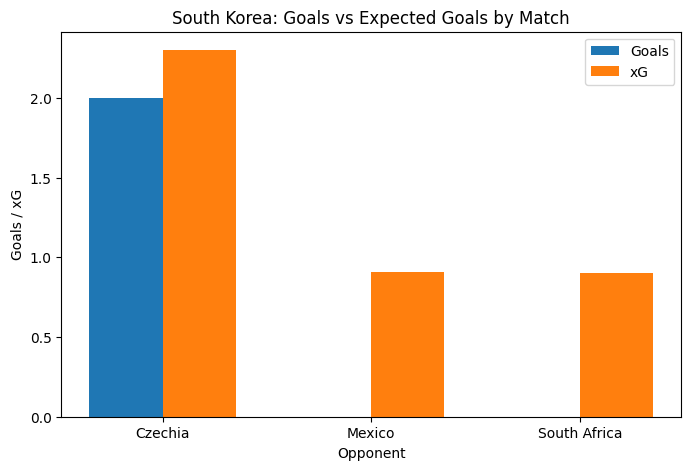

In [21]:
x = np.arange(len(match_analysis["opponent"]))
width = 0.35

plt.figure(figsize=(8,5))
plt.bar(x - width/2, match_analysis["goals_for"], width, label="Goals")
plt.bar(x + width/2, match_analysis["xg_for"], width, label="xG")
plt.xticks(x, match_analysis["opponent"])
plt.title("South Korea: Goals vs Expected Goals by Match")
plt.xlabel("Opponent")
plt.ylabel("Goals / xG")
plt.legend()
plt.show()

The chart shows that South Korea's actual goals were lower than xG in key matches, supporting the earlier finding that finishing and chance conversion were major issues.

### Chart 2: Possession Productivity

This chart shows how much xG South Korea generated relative to its possession share in each match. A lower value suggests that South Korea had more possession but did not turn that possession into enough attacking threat.

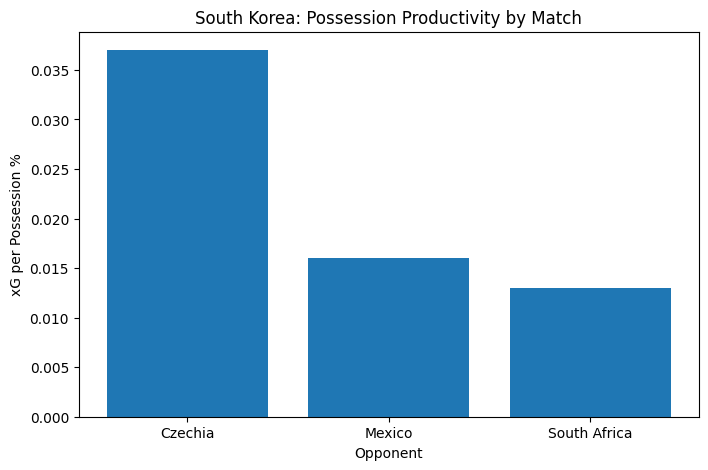

In [22]:
plt.figure(figsize=(8,5))
plt.bar(
    possession_productivity["opponent"],
    possession_productivity["xg_per_possession_pct"]
)

plt.title("South Korea: Possession Productivity by Match")
plt.xlabel("Opponent")
plt.ylabel("xG per Possession %")
plt.show()

This chart helps evaluate whether South Korea's possession was productive. If a match shows high possession but low xG per possession percentage, it may suggest sterile possession or tactical inefficiency in turning ball control into high-quality chances.

### Chart 3: Shot on Target Rate

This chart shows the percentage of South Korea's shots that were on target in each match. A lower shot-on-target rate suggests that South Korea struggled with shot accuracy and final execution, even when the team created shooting opportunities.

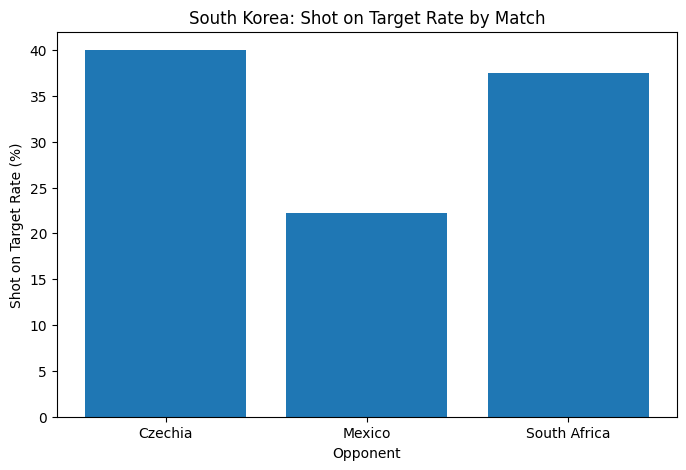

In [23]:
efficiency["shot_on_target_rate_pct"] = efficiency["shot_on_target_rate"] * 100

plt.figure(figsize=(8,5))
plt.bar(efficiency["opponent"], efficiency["shot_on_target_rate_pct"])
plt.title("South Korea: Shot on Target Rate by Match")
plt.xlabel("Opponent")
plt.ylabel("Shot on Target Rate (%)")
plt.show()

This chart supports the finishing analysis by showing whether South Korea's shots were consistently testing the goalkeeper. Combined with the goals vs xG chart, it helps distinguish between chance creation and shot execution.

## 9. Initial Conclusion

Based on the match-level data, South Korea's underperformance appears to be driven more by finishing and attacking efficiency than by being completely outplayed. South Korea generated more total xG and more total shots than its opponents, but scored only 2 goals from 4.11 xG. This indicates a clear problem in converting chances into goals.

However, the data also suggests a possible tactical efficiency issue. Despite averaging 62.7% possession, South Korea did not consistently turn possession into goals or positive match outcomes. This means that further analysis should examine whether the team’s possession was productive, especially in the final third.

At this stage, the data does not support the simple conclusion that South Korea performed poorly across all areas. Instead, the evidence points to a more specific and frustrating problem: South Korea created enough attacking opportunities to expect better results, but failed to convert those chances and did not consistently translate possession into decisive attacking outcomes.

The next stage of this project should therefore examine player-level finishing, shot quality, tactical patterns, squad selection, and coaching decisions to better understand why South Korea’s underlying performance did not translate into results.


## 10. Limitations

This project uses match-level statistics from South Korea’s three group-stage matches. While these numbers are useful for identifying broad performance patterns, they cannot fully explain coaching decisions, tactical preparation, player selection, or institutional issues within Korean football.

Because of this, the analysis should not be interpreted as proof that one individual, coach, or organization caused the results. Instead, the data shows where South Korea’s performance fell short and points to areas that require deeper investigation.


## 11. Further Analysis: Beyond Match-Level Statistics

This analysis suggests that South Korea was not completely outplayed in the group stage. The team generated more total expected goals, more total shots, and higher xG per shot than its opponents, but failed to convert those advantages into results. This raises a broader question: if the performance indicators were not overwhelmingly poor, why did the outcomes still fall short?

Match-level data alone cannot prove whether the problem came from individual execution, tactical preparation, squad selection, coaching decisions, or institutional structure. However, the numbers point toward several areas that deserve further investigation.

### 1. Player Execution and Finishing

The clearest issue in the data is finishing. South Korea scored only 2 goals from 4.11 xG, producing a finishing gap of -2.11. This suggests that the team created enough chances to score more than it did, but failed to turn those chances into goals.

Further analysis should examine player-level xG, shot locations, shot types, and big chances missed to identify whether the finishing problem was concentrated among specific players or spread across the team.

### 2. Tactical Efficiency and Possession Quality

South Korea averaged 62.7% possession, but that possession did not consistently lead to goals or positive match outcomes. This raises the question of whether South Korea’s possession was productive or sterile.

A deeper tactical analysis should examine final-third entries, progressive passes, touches in the opposition box, crossing patterns, shot locations, and whether South Korea was able to create chances from possession against organized defensive blocks.

### 3. Coaching, Preparation, and Decision-Making

Modern football is not only decided by the individual ability of players. Coaching, tactical preparation, opponent analysis, squad selection, and in-game adjustments all shape performance. A strong playing career does not automatically guarantee managerial effectiveness, and national-team success requires more than individual reputation.

Because public match statistics cannot directly measure coaching quality, this project cannot conclude that coaching or tactical preparation was the main cause of South Korea’s elimination. However, the gap between competitive underlying numbers and poor final results suggests that future analysis should examine whether team selection, tactical setup, substitutions, and opponent-specific preparation helped or limited South Korea's performance.

### 4. Broader Questions for Korean Football

This project also raises broader questions about South Korea's football development structure. If similar gaps between underlying performance and tournament results continue to appear, the issue may not be limited to one match, one player, or one manager.

Further research could investigate whether recurring issues in coaching appointments, player development, tactical analysis, organizational decision-making, and long-term development structures affect South Korea's ability to compete consistently at the highest level.

The key conclusion is not that South Korea simply “played badly.” Instead, the data suggests a more specific and frustrating problem: South Korea produced enough underlying performance to expect better results, but failed to convert that into goals, wins, and progression. Understanding why that gap exists requires analysis beyond the box score.
